In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")

In [30]:
df = pd.read_csv("data_example.csv")

print(f"\nOriginal dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())


Original dataset: (4240, 16)
Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

Missing values per column:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [99]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


from matplotlib import pyplot as plt
df['male'].plot(kind='hist', bins=20, title='male')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['education'].plot(kind='hist', bins=20, title='education')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['currentSmoker'].plot(kind='hist', bins=20, title='currentSmoker')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='currentSmoker', y='cigsPerDay', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['male'].plot(kind='line', figsize=(8, 4), title='male')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['education'].plot(kind='line', figsize=(8, 4), title='education')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['currentSmoker'].plot(kind='line', figsize=(8, 4), title='currentSmoker')
plt.gca().spines[['top', 'right']].set_visible(False)

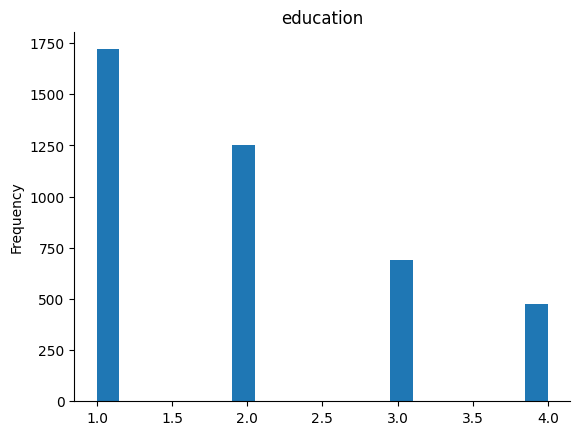

In [100]:
from matplotlib import pyplot as plt
df['education'].plot(kind='hist', bins=20, title='education')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [94]:
df['education'].value_counts()

,count
education,
1.0,1720
2.0,1253
3.0,689
4.0,473


In [32]:
# Clean the dataset
df_clean = df.dropna()

print(f"\nCleaned dataset: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Cleaned dataset: (3658, 16)
Rows removed: 582


In [95]:
# Create categorical labels
df_clean['Gender'] = df_clean['male'].map({0: 'Female', 1: 'Male'})
df_clean['CHD_Risk'] = df_clean['TenYearCHD'].map({0: 'Low Risk', 1: 'High Risk'})
df_clean['Smoking_Status'] = df_clean['currentSmoker'].map({0: 'Non-Smoker', 1: 'Smoker'})
df_clean['Diabetes_Status'] = df_clean['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})
df_clean['Hypertension'] = df_clean['prevalentHyp'].map({0: 'Normal', 1: 'Hypertensive'})
df_clean['Education'] = df_clean['education'].map({
    1: 'Some HS',
    2: 'HS/GED',
    3: 'Some College',
    4: 'College'
})

# Age groups
df_clean['Age_Group'] = pd.cut(df_clean['age'],
                               bins=[30, 40, 50, 60, 70],
                               labels=['30-40', '40-50', '50-60', '60-70'])

print("\nData ready!")
print(f"Total patients: {len(df_clean)}")
print(f"High CHD risk: {df_clean['TenYearCHD'].sum()} ({df_clean['TenYearCHD'].mean()*100:.1f}%)")
df_clean.shape


Data ready!
Total patients: 3658
High CHD risk: 557 (15.2%)


(3658, 23)

In [96]:
df_clean.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,heartRate,glucose,TenYearCHD,Gender,CHD_Risk,Smoking_Status,Diabetes_Status,Hypertension,Education,Age_Group
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,...,80.0,77.0,0,Male,Low Risk,Non-Smoker,No Diabetes,Normal,College,30-40
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,...,95.0,76.0,0,Female,Low Risk,Non-Smoker,No Diabetes,Normal,HS/GED,40-50
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,...,75.0,70.0,0,Male,Low Risk,Smoker,No Diabetes,Normal,Some HS,40-50
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,...,65.0,103.0,1,Female,High Risk,Smoker,No Diabetes,Hypertensive,Some College,60-70
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,...,85.0,85.0,0,Female,Low Risk,Smoker,No Diabetes,Normal,Some College,40-50


## 1. relational


Question: Does age relate to systolic blood pressure?


Text(0.5, 1.02, 'Age vs Systolic Blood Pressure\n(Each dot = one patient)')

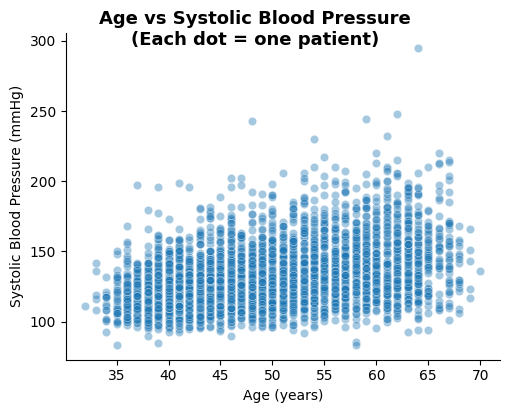

In [34]:
# scatter
g = sns.relplot(
    data=df_clean,
    x='age',
    y='sysBP',
    kind='scatter',
    alpha=0.4,
    height=4,
    aspect=1.3
)

g.set_axis_labels("Age (years)", "Systolic Blood Pressure (mmHg)")
g.fig.suptitle(
    "Age vs Systolic Blood Pressure\n(Each dot = one patient)",
    fontsize=13,
    fontweight='bold',
    y=1.02
)


Text(0.5, 1.02, 'Age vs Blood Pressure by CHD Risk')

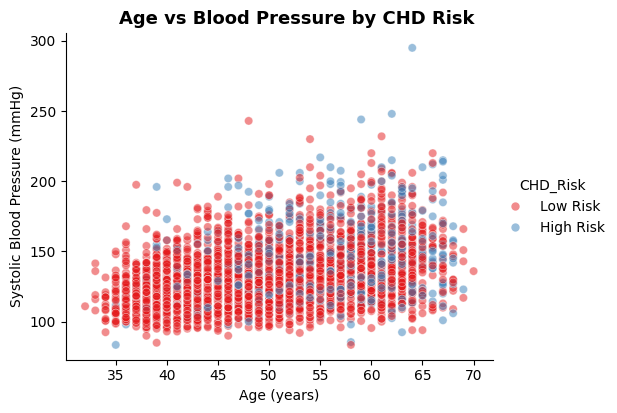

In [47]:
# 1.1 scatterplot
g = sns.relplot(
    data=df_clean,
    x='age',
    y='sysBP',
    hue='CHD_Risk',
    kind='scatter',
    alpha=0.5,
    height=4,
    aspect=1.3,
    palette='Set1'
)

g.set_axis_labels("Age (years)", "Systolic Blood Pressure (mmHg)")
g.fig.suptitle(
    "Age vs Blood Pressure by CHD Risk",
    fontsize=13,
    fontweight='bold',
    y=1.02
)


Text(0.5, 1.02, 'Age vs Blood Pressure')

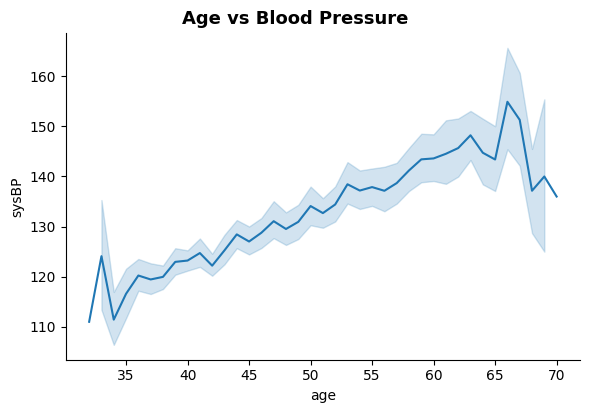

In [45]:
# Lineplot
g = sns.relplot(
    data=df_clean,
    x='age',
    y='sysBP',
    kind='line',
    height=4,
    aspect=1.5
)

g.fig.suptitle(
    "Age vs Blood Pressure",
    fontsize=13,
    fontweight='bold',
    y=1.02
)


Text(0.5, 1.02, 'Age vs Blood Pressure by CHD Risk')

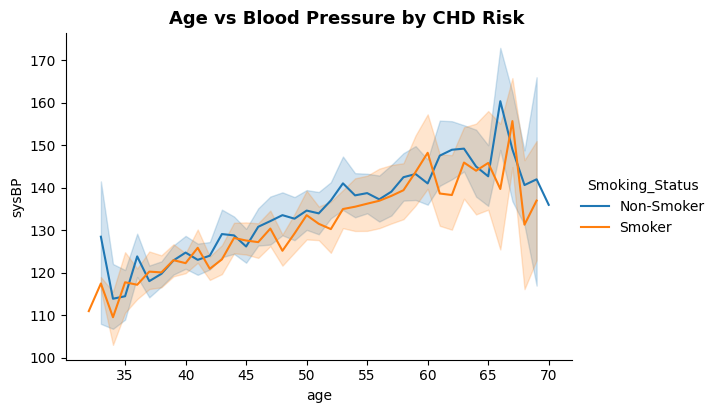

In [51]:
# Lineplot
g = sns.relplot(
    data=df_clean,
    x='age',
    y='sysBP',
    hue='Smoking_Status',
    kind='line',
    height=4,
    aspect=1.5
)

g.fig.suptitle(
    "Age vs Blood Pressure by CHD Risk",
    fontsize=13,
    fontweight='bold',
    y=1.02
)

## 2. distribution

Text(0.5, 1.02, 'Histogram of Systolic Blood Pressure')

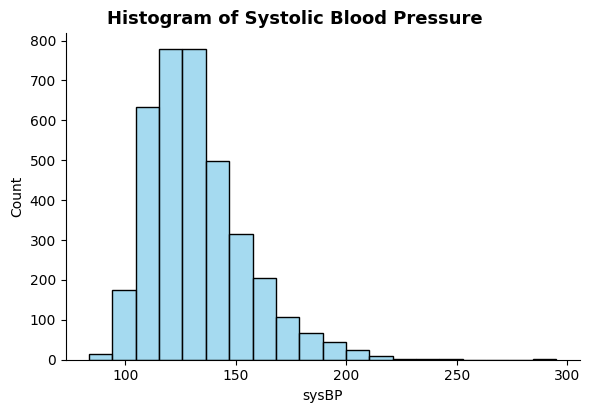

In [54]:
# Histogram
g = sns.displot(
    df_clean,
    x='sysBP',
    bins=20,
    kind='hist',
    height=4,
    aspect=1.5,
    color='skyblue'
)

g.fig.suptitle(
    "Histogram of Systolic Blood Pressure",
    fontsize=13,
    fontweight='bold',
    y=1.02
)

Text(0.5, 1.02, 'Smoothed Distribution (KDE) of Systolic Blood Pressure')

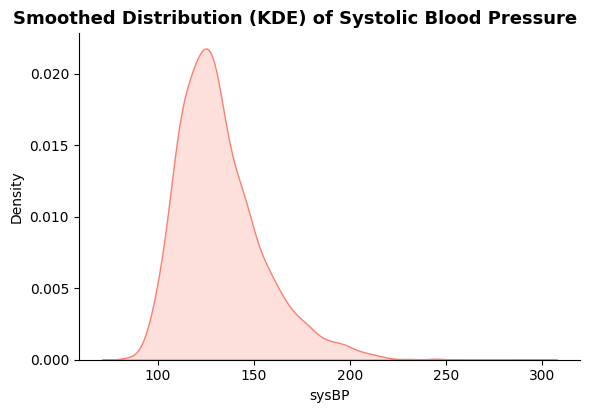

In [55]:
# kdeplot
g = sns.displot(
    df_clean,
    x='sysBP',
    kind='kde',
    fill=True,
    height=4,
    aspect=1.5,
    color='salmon'
)

g.fig.suptitle(
    "Smoothed Distribution (KDE) of Systolic Blood Pressure",
    fontsize=13,
    fontweight='bold',
    y=1.02
)

Text(0.5, 1.02, 'Empirical CDF of Systolic Blood Pressure')

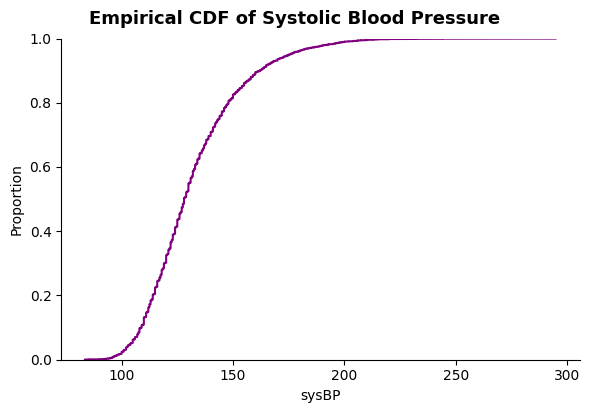

In [56]:
g = sns.displot(
    df_clean,
    x='sysBP',
    kind='ecdf',
    height=4,
    aspect=1.5,
    color='purple'
)

g.fig.suptitle(
    "Empirical CDF of Systolic Blood Pressure",
    fontsize=13,
    fontweight='bold',
    y=1.02
)

Question: What fraction of patients have BMI below certain thresholds?


<Axes: xlabel='BMI', ylabel='Proportion'>

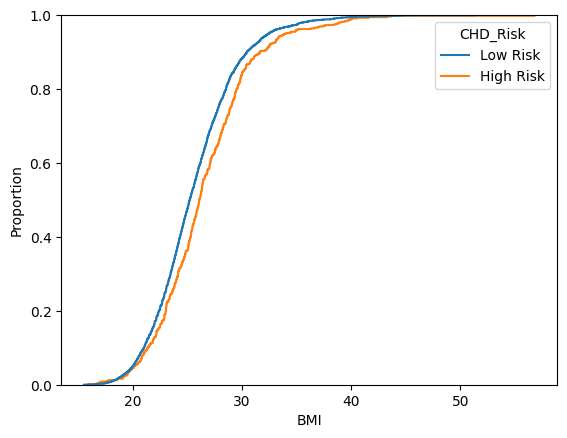

In [25]:
print("Question: What fraction of patients have BMI below certain thresholds?")
sns.ecdfplot(df_clean, x='BMI', hue='CHD_Risk')

## 3. Categorical

Smokers avg BP: 129.3 mmHg
Non-smokers avg BP: 135.3 mmHg
Difference: -5.9 mmHg


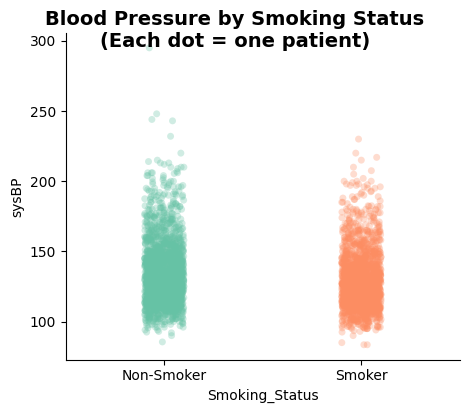

In [71]:
# 3.1 Stripplot
g = sns.catplot(data=df_clean,
                x='Smoking_Status',
                y='sysBP',
                kind='strip',
                alpha=0.3,
                height=4,
                aspect=1.2,
                palette='Set2')

g.fig.suptitle('Blood Pressure by Smoking Status\n(Each dot = one patient)', fontsize=14, fontweight='bold', y=1.02)

smoker_bp = df_clean[df_clean['currentSmoker']==1]['sysBP'].mean()
nonsmoker_bp = df_clean[df_clean['currentSmoker']==0]['sysBP'].mean()
print(f"Smokers avg BP: {smoker_bp:.1f} mmHg")
print(f"Non-smokers avg BP: {nonsmoker_bp:.1f} mmHg")
print(f"Difference: {smoker_bp - nonsmoker_bp:.1f} mmHg")

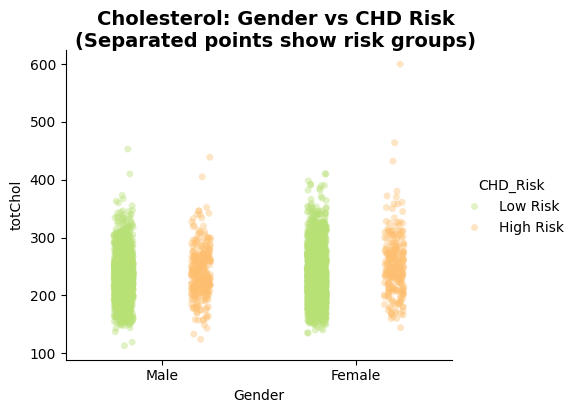

In [72]:
# Stripplot
g = sns.catplot(data=df_clean,
                x='Gender',
                y='totChol',
                hue='CHD_Risk',
                kind='strip',
                dodge=True,
                alpha=0.4,
                height=4,
                aspect=1.2,
                palette='RdYlGn_r')

g.fig.suptitle('Cholesterol: Gender vs CHD Risk\n(Separated points show risk groups)',
               fontsize=14, fontweight='bold', y=1.02)

Diabetic patients analyzed: 99
Average glucose: 170.0 mg/dL


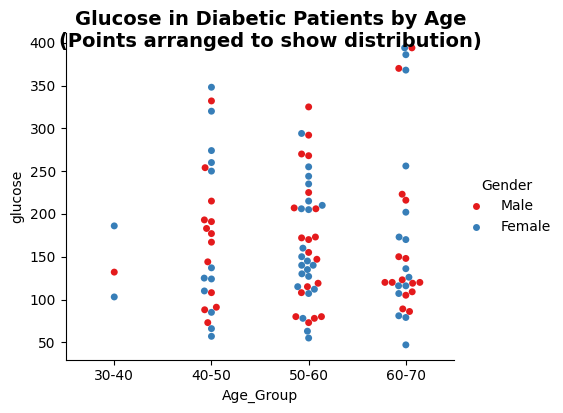

In [75]:
# Swarmplot
diabetes_patients = df_clean[df_clean['diabetes']==1]
sample_size = min(300, len(diabetes_patients))
diabetes_sample = diabetes_patients.sample(sample_size, random_state=42)

g = sns.catplot(data=diabetes_sample,
                x='Age_Group',
                y='glucose',
                kind='swarm',
                hue='Gender',
                palette='Set1',
                height=4,
                aspect=1.2)

g.fig.suptitle('Glucose in Diabetic Patients by Age\n(Points arranged to show distribution)',
               fontsize=14, fontweight='bold', y=1.02)

print(f"Diabetic patients analyzed: {len(diabetes_sample)}")
print(f"Average glucose: {diabetes_sample['glucose'].mean():.1f} mg/dL")

Text(0.5, 1.02, 'Heart Rate: Hypertensive vs Normal\n(Color shows gender)')

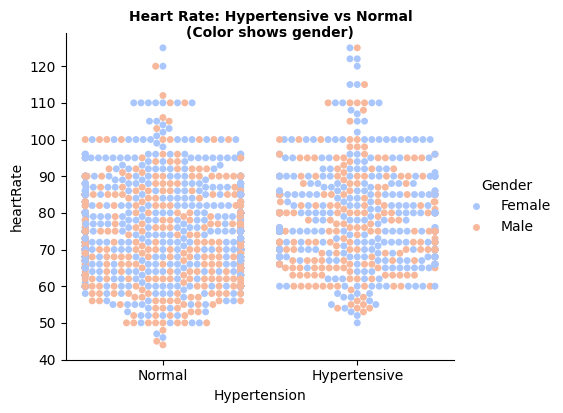

In [77]:
# swarmplot
sample = df_clean.sample(2000, random_state=42)

g = sns.catplot(data=sample,
                x='Hypertension',
                y='heartRate',
                hue='Gender',
                kind='swarm',
                palette='coolwarm',
                height=4,
                aspect=1.2)

g.fig.suptitle('Heart Rate: Hypertensive vs Normal\n(Color shows gender)', fontsize=10, fontweight='bold', y=1.02)

Text(0.5, 1.02, 'Blood Pressure: Diabetes × Hypertension\n(Combined effect of two conditions)')

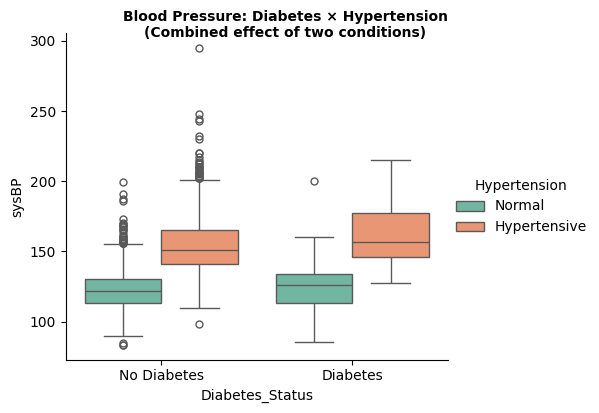

In [78]:
#boxplot
g = sns.catplot(data=df_clean,
                x='Diabetes_Status',
                y='sysBP',
                hue='Hypertension',
                kind='box',
                palette='Set2',
                height=4,
                aspect=1.2)

g.fig.suptitle('Blood Pressure: Diabetes × Hypertension\n(Combined effect of two conditions)',
               fontsize=10, fontweight='bold', y=1.02)

High risk avg age: 54.3 years
Low risk avg age: 48.7 years
Age difference: 5.6 years


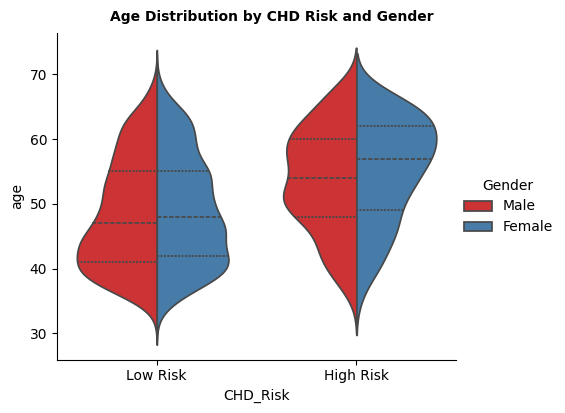

In [98]:
# Violinplot
g = sns.catplot(data=df_clean,
                x='CHD_Risk',
                y='age',
                hue='Gender',
                kind='violin',
                split=True,
                palette='Set1',
                height=4,
                aspect=1.2,
                inner='quartile')

#quartile, box, point, stick

g.fig.suptitle('Age Distribution by CHD Risk and Gender',
               fontsize=10, fontweight='bold', y=1.02)

high_risk_age = df_clean[df_clean['TenYearCHD']==1]['age'].mean()
low_risk_age = df_clean[df_clean['TenYearCHD']==0]['age'].mean()
print(f"High risk avg age: {high_risk_age:.1f} years")
print(f"Low risk avg age: {low_risk_age:.1f} years")
print(f"Age difference: {high_risk_age - low_risk_age:.1f} years")

Text(0.5, 1.02, 'Smoking Intensity vs Blood Pressure)')

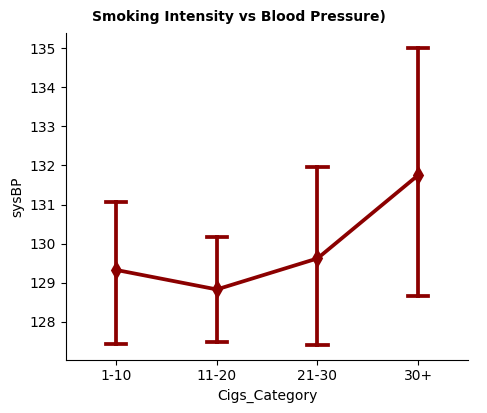

In [90]:
#pointplot
smokers = df_clean[df_clean['currentSmoker']==1].copy()
smokers['Cigs_Category'] = pd.cut(smokers['cigsPerDay'],
                                   bins=[0, 10, 20, 30, 100],
                                   labels=['1-10', '11-20', '21-30', '30+'])

g = sns.catplot(data=smokers,
                x='Cigs_Category',
                y='sysBP',
                kind='point',
                height=4,
                aspect=1.2,
                color='darkred',
                markers='d',
                capsize=0.2)

g.fig.suptitle('Smoking Intensity vs Blood Pressure)',
               fontsize=10, fontweight='bold', y=1.02)

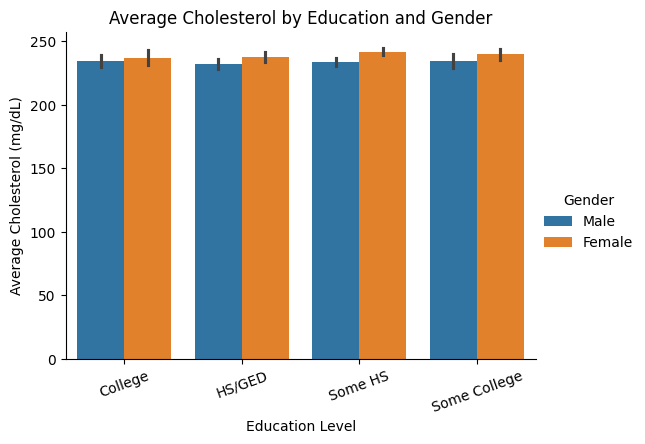

In [70]:
#barplot
sns.catplot(
    data=df_clean,
    x='Education',
    y='totChol',
    hue='Gender',
    kind='bar',
    height=4,
    aspect=1.4
)

plt.xlabel("Education Level")
plt.ylabel("Average Cholesterol (mg/dL)")
plt.xticks(rotation=20)
plt.title("Average Cholesterol by Education and Gender")
plt.show()